# Notebook 02 — Transaction Features

**Source files:** `transactions.csv` (v1, 21.5M rows, up to end-2016) + `transactions_v2.csv` (v2, 1.4M rows, Jan–Mar 2017) — UNION ALL via DuckDB  
**Label file:** `train_v2.csv` (March 2017 churn labels, 970,960 customers)  
**Key column:** `msno` (not `customer_id`)  
**QC note:** `actual_amount_paid` can exceed `plan_list_price` — `discount_rate` is clamped to 0 minimum

## Section 1 — Load Data & Run SQL Query

In [1]:
import pandas as pd
import numpy as np
import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path

ROOT    = Path("..").resolve()
DATA    = ROOT / "data"
OUTPUTS = ROOT / "outputs"
QUERIES = ROOT / "queries"
OUTPUTS.mkdir(exist_ok=True)

print(f"Project root : {ROOT}")
print(f"Data dir     : {DATA}")

Project root : C:\Users\h11la\OneDrive\Documents\00 Portfolio\Customer Analytics ML Pipeline\retail-clv-churn-prediction
Data dir     : C:\Users\h11la\OneDrive\Documents\00 Portfolio\Customer Analytics ML Pipeline\retail-clv-churn-prediction\data


In [2]:
con = duckdb.connect()

# UNION ALL both transaction files into a single view
con.execute(f"""
    CREATE OR REPLACE VIEW transactions AS
    SELECT * FROM read_csv_auto('{DATA}/transactions.csv')
    UNION ALL
    SELECT * FROM read_csv_auto('{DATA}/transactions_v2.csv')
""")

# Load train_v2.csv (March 2017 labels) as a DuckDB table for fast joins
con.execute(f"""
    CREATE OR REPLACE TABLE train_labels AS
    SELECT * FROM read_csv_auto('{DATA}/train_v2.csv')
""")

tx_total = con.execute("SELECT COUNT(*) FROM transactions").fetchone()[0]
lbl_total = con.execute("SELECT COUNT(*) FROM train_labels").fetchone()[0]
print(f"transactions  : {tx_total:,} rows  (v1 + v2 UNION ALL)")
print(f"train_labels  : {lbl_total:,} rows  (train_v2.csv — March 2017)")

transactions  : 22,978,755 rows  (v1 + v2 UNION ALL)
train_labels  : 970,960 rows  (train_v2.csv — March 2017)


In [3]:
# Read SQL from file and execute
sql = (QUERIES / "transaction_features.sql").read_text()
print("Running query from queries/transaction_features.sql ...")
tx_features = con.execute(sql).df()

print(f"\nShape: {tx_features.shape[0]:,} rows x {tx_features.shape[1]} cols")
print(f"\nNull counts per column:")
nulls = tx_features.isnull().sum()
null_pct = (nulls / len(tx_features) * 100).round(2)
print(pd.DataFrame({"nulls": nulls, "null_%": null_pct}).to_string())
print(f"\nSummary statistics:")
print(tx_features.drop(columns=["msno"]).describe().round(2).to_string())

Running query from queries/transaction_features.sql ...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


Shape: 970,960 rows x 14 cols

Null counts per column:
                   nulls  null_%
msno                   0    0.00
total_paid             0    0.00
avg_payment            0    0.00
max_payment            0    0.00
discount_rate        451    0.05
n_transactions         0    0.00
avg_plan_days          0    0.00
auto_renew_rate        0    0.00
cancel_rate            0    0.00
first_transaction      0    0.00
last_transaction       0    0.00
days_as_member         0    0.00
last_expire_date       0    0.00
n_payment_methods      0    0.00

Summary statistics:


       total_paid  avg_payment  max_payment  discount_rate  n_transactions  avg_plan_days  auto_renew_rate  cancel_rate  first_transaction  last_transaction  days_as_member  last_expire_date  n_payment_methods
count   970960.00    970960.00    970960.00      970509.00       970960.00      970960.00        970960.00    970960.00          970960.00         970960.00       970960.00         970960.00          970960.00
mean      2301.65       149.85       186.62           0.01           16.74          34.14             0.87         0.02        20154941.55       20170198.89          513.55       20170535.22               1.19
std       1310.16       141.78       254.71           0.04            8.74          33.12             0.31         0.04            6071.40           1079.60          258.16           1159.03               0.51
min          0.00         0.00         0.00           0.00            1.00           0.00             0.00         0.00        20150101.00       20150102.00    

## Section 2 — Distributions

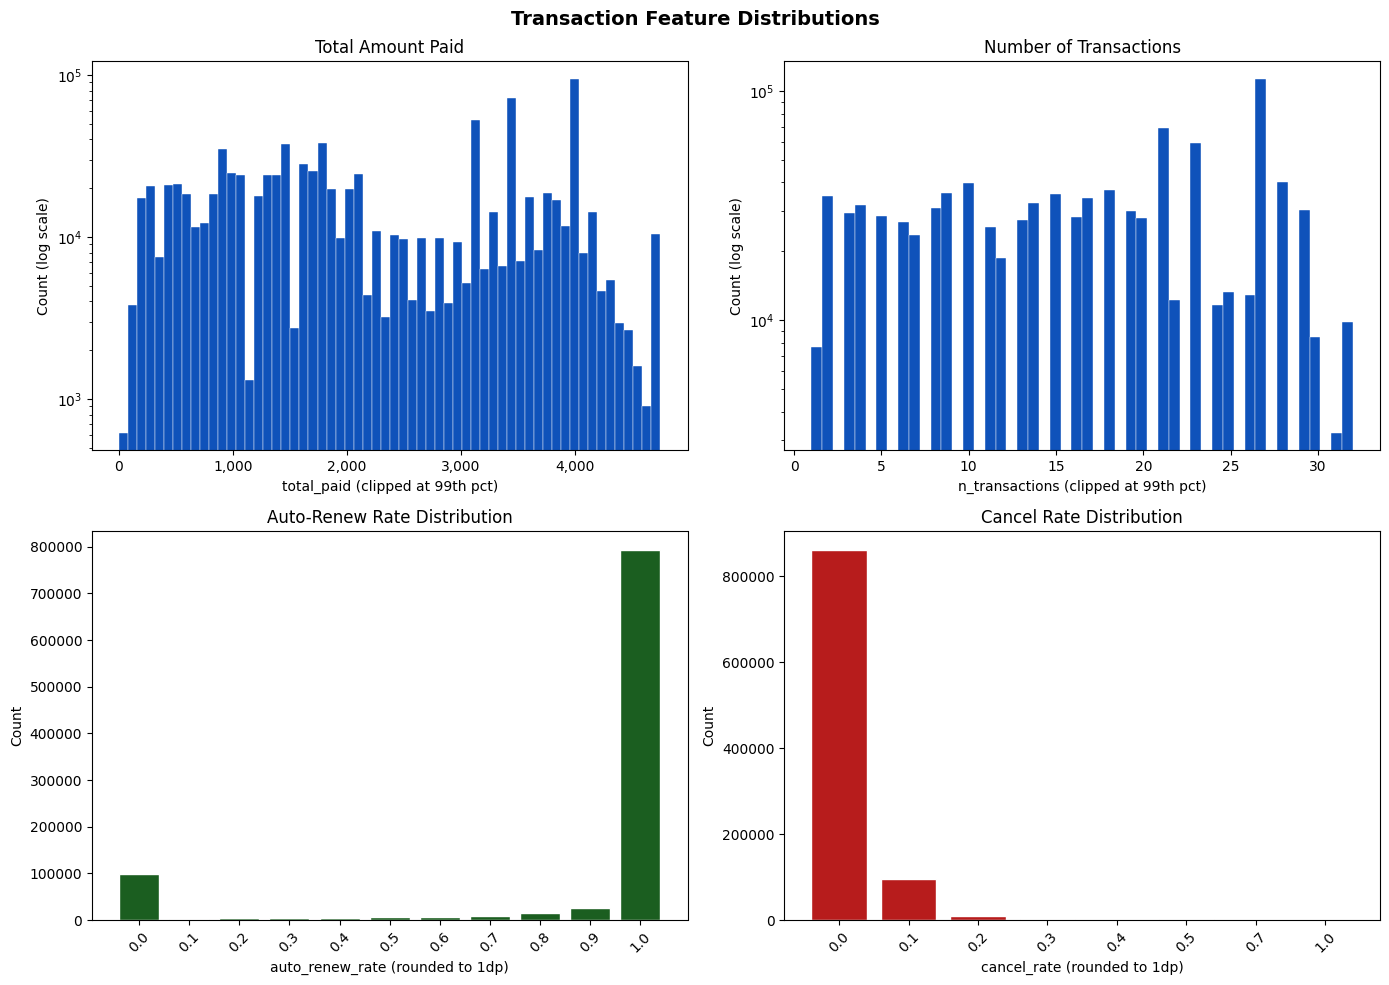

Saved: outputs/02_transaction_distributions.png


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Transaction Feature Distributions", fontsize=14, fontweight="bold")

# 1. total_paid — log scale
ax = axes[0, 0]
ax.hist(tx_features["total_paid"].clip(upper=tx_features["total_paid"].quantile(0.99)),
        bins=60, color="#0F52BA", edgecolor="white", linewidth=0.3)
ax.set_yscale("log")
ax.set_xlabel("total_paid (clipped at 99th pct)")
ax.set_ylabel("Count (log scale)")
ax.set_title("Total Amount Paid")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# 2. n_transactions
ax = axes[0, 1]
cap = tx_features["n_transactions"].quantile(0.99)
ax.hist(tx_features["n_transactions"].clip(upper=cap),
        bins=50, color="#0F52BA", edgecolor="white", linewidth=0.3)
ax.set_yscale("log")
ax.set_xlabel("n_transactions (clipped at 99th pct)")
ax.set_ylabel("Count (log scale)")
ax.set_title("Number of Transactions")

# 3. auto_renew_rate — bar chart of rounded buckets
ax = axes[1, 0]
buckets = tx_features["auto_renew_rate"].round(1).value_counts().sort_index()
ax.bar(buckets.index.astype(str), buckets.values, color="#1B5E20", edgecolor="white")
ax.set_xlabel("auto_renew_rate (rounded to 1dp)")
ax.set_ylabel("Count")
ax.set_title("Auto-Renew Rate Distribution")
ax.tick_params(axis="x", rotation=45)

# 4. cancel_rate — bar chart
ax = axes[1, 1]
cbuckets = tx_features["cancel_rate"].round(1).value_counts().sort_index()
ax.bar(cbuckets.index.astype(str), cbuckets.values, color="#B71C1C", edgecolor="white")
ax.set_xlabel("cancel_rate (rounded to 1dp)")
ax.set_ylabel("Count")
ax.set_title("Cancel Rate Distribution")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(OUTPUTS / "02_transaction_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/02_transaction_distributions.png")

## Section 3 — Churn Signal: Auto-Renew Rate vs Churn

Churn rate by auto_renew_rate bucket:
                   n_customers  churned  churn_rate
auto_renew_bucket                                  
Low (0–0.25)            105457    43035       40.81
Mid (0.25–0.75)          34138     4589       13.44
High (0.75–1.0)         831365    39706        4.78

Interpretation: customers who rarely use auto-renew (Low bucket) churn at a much higher rate than those who always auto-renew (High bucket), confirming auto_renew_rate is a strong churn signal.


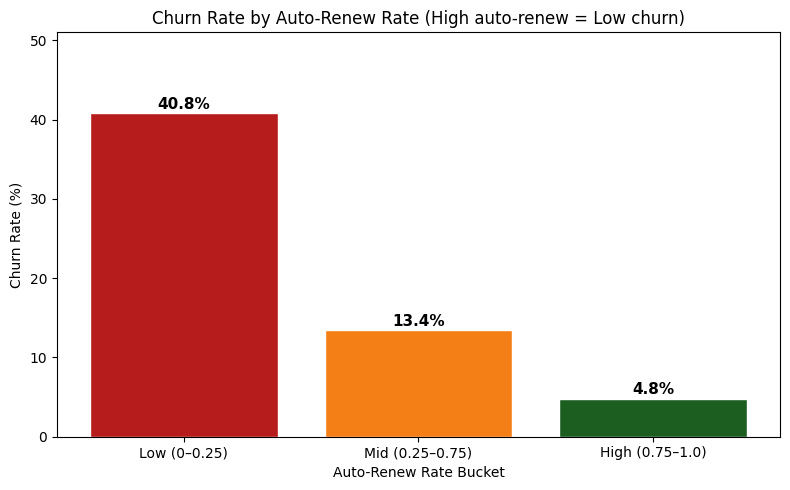

Saved: outputs/02_churn_by_auto_renew.png


In [5]:
# Join churn labels onto tx_features for the cross-tab
train_v2 = pd.read_csv(DATA / "train_v2.csv")
df = tx_features.merge(train_v2[["msno", "is_churn"]], on="msno", how="inner")

# Bucket auto_renew_rate into 3 groups
bins   = [-0.001, 0.25, 0.75, 1.001]
labels = ["Low (0–0.25)", "Mid (0.25–0.75)", "High (0.75–1.0)"]
df["auto_renew_bucket"] = pd.cut(df["auto_renew_rate"], bins=bins, labels=labels)

cross = (
    df.groupby("auto_renew_bucket", observed=True)["is_churn"]
    .agg(n_customers="count", churned="sum")
    .assign(churn_rate=lambda x: (x["churned"] / x["n_customers"] * 100).round(2))
)
print("Churn rate by auto_renew_rate bucket:")
print(cross.to_string())
print()
print("Interpretation: customers who rarely use auto-renew (Low bucket) churn at a much "
      "higher rate than those who always auto-renew (High bucket), confirming auto_renew_rate "
      "is a strong churn signal.")

# Bar chart
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(cross.index.astype(str), cross["churn_rate"],
              color=["#B71C1C", "#F57F17", "#1B5E20"], edgecolor="white")
for bar, val in zip(bars, cross["churn_rate"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f"{val:.1f}%", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_xlabel("Auto-Renew Rate Bucket")
ax.set_ylabel("Churn Rate (%)")
ax.set_title("Churn Rate by Auto-Renew Rate (High auto-renew = Low churn)")
ax.set_ylim(0, cross["churn_rate"].max() * 1.25)
plt.tight_layout()
plt.savefig(OUTPUTS / "02_churn_by_auto_renew.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/02_churn_by_auto_renew.png")

## Section 4 — Save

In [6]:
out_path = OUTPUTS / "transaction_features.parquet"
tx_features.to_parquet(out_path, index=False)
print(f"Saved: {out_path}")
print(f"Shape: {tx_features.shape[0]:,} rows x {tx_features.shape[1]} cols")
print(f"Columns: {list(tx_features.columns)}")

Saved: C:\Users\h11la\OneDrive\Documents\00 Portfolio\Customer Analytics ML Pipeline\retail-clv-churn-prediction\outputs\transaction_features.parquet
Shape: 970,960 rows x 14 cols
Columns: ['msno', 'total_paid', 'avg_payment', 'max_payment', 'discount_rate', 'n_transactions', 'avg_plan_days', 'auto_renew_rate', 'cancel_rate', 'first_transaction', 'last_transaction', 'days_as_member', 'last_expire_date', 'n_payment_methods']
